In [1]:
# Setup automatico para Google Colab: clona o repo para ter acesso ao
# modulo .py e ao dataset desta pasta (sem efeito quando rodado localmente).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Algoritmos-Base/03-MLP-Neuralnet-Sklearn")
    get_ipython().system('pip install -q openpyxl')


# MLP com scikit-learn (equivalente ao pacote `neuralnet` do R)

Traduzido de `Codigo01_Seno_MLP_neuralnet.R` e `Codigo01_FUNCAO_MLP_neuralnet.R`.

O notebook anterior (`02-MLP-Backpropagation-Manual/`) implementou o
backpropagation "na mao". Na pratica, usa-se uma biblioteca madura para
treinar MLPs — em R, o pacote `neuralnet`; em Python, `sklearn.neural_network.MLPRegressor`
cumpre o mesmo papel: mesma arquitetura (uma camada escondida, ativacao
configuravel, saida linear), mas com otimizacao numerica robusta
(aqui, L-BFGS) e sem precisar derivar gradientes manualmente.

Este notebook repete o experimento em dois datasets: o seno ruidoso
(`Seno.xlsx`, ja usado antes) e uma funcao mais irregular (`funcao.xlsx`,
que traz tambem `xgrd`/`ymean` — a funcao alvo real, sem ruido, para
comparacao visual).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mlp_sklearn import load_data, fit_mlp, predict

plt.rcParams["figure.figsize"] = (7, 4.5)


## Caso 1: funcao seno

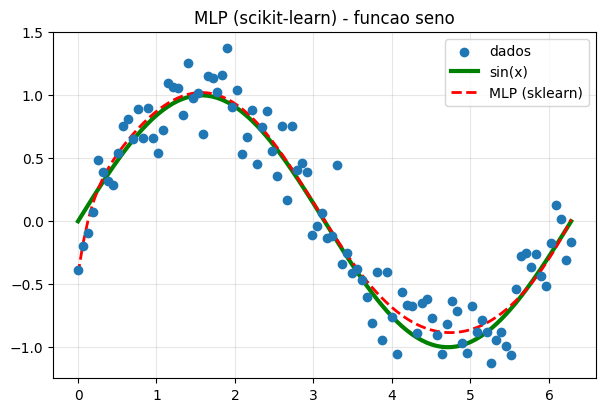

In [3]:
dt_seno = load_data("data/Seno.xlsx")
x_seno = dt_seno["x"].to_numpy(dtype=float)
y_seno = dt_seno["y"].to_numpy(dtype=float)

model_seno = fit_mlp(x_seno, y_seno, hidden_layer_sizes=(6,), activation="tanh")
y_hat_seno = predict(model_seno, x_seno)

order = np.argsort(x_seno)
plt.scatter(x_seno, y_seno, color="tab:blue", label="dados", zorder=3)
plt.plot(x_seno[order], np.sin(x_seno[order]), color="green", lw=3, label="sin(x)")
plt.plot(x_seno[order], y_hat_seno[order], color="red", lw=2, ls="--", label="MLP (sklearn)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP (scikit-learn) - funcao seno")
plt.show()


## Caso 2: funcao generica (`funcao.xlsx`)

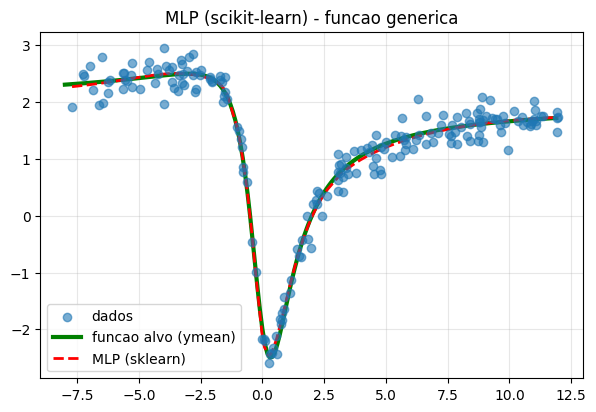

In [4]:
dt_fn = load_data("data/funcao.xlsx")
x_fn = dt_fn["x"].to_numpy(dtype=float)
y_fn = dt_fn["y"].to_numpy(dtype=float)

model_fn = fit_mlp(x_fn, y_fn, hidden_layer_sizes=(6,), activation="tanh")
y_hat_fn = predict(model_fn, x_fn)

order_fn = np.argsort(x_fn)
plt.scatter(x_fn, y_fn, color="tab:blue", label="dados", zorder=3, alpha=0.6)
plt.plot(dt_fn["xgrd"], dt_fn["ymean"], color="green", lw=3, label="funcao alvo (ymean)")
plt.plot(x_fn[order_fn], y_hat_fn[order_fn], color="red", lw=2, ls="--", label="MLP (sklearn)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("MLP (scikit-learn) - funcao generica")
plt.show()


### Escolha dos hiperparametros

- **`hidden_layer_sizes=(6,)`**: mesma topologia usada no script original em R
  (`hidden = c(6)`), suficiente para capturar a curvatura de ambas as
  funcoes sem ser tao grande a ponto de decorar o ruido.
- **`activation="tanh"`**: replica o `act.fct = 'tanh'` do R; satura suave e
  simetricamente em torno de zero, adequada para funcoes oscilatorias como
  seno.
- **`solver="lbfgs"`**: para datasets pequenos (100-200 pontos), L-BFGS
  converge de forma mais estavel e reprodutivel que otimizadores baseados em
  mini-batch (`adam`, `sgd`), que sao pensados para datasets grandes.


## Interpretacao das metricas

`model.score()` do scikit-learn retorna diretamente o R² sobre os dados
informados. Combinado ao RMSE, resume o quão bem o MLP recupera a forma da
funcao alvo a partir dos dados ruidosos.


In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


print("Seno   -> R2:", round(model_seno.score(x_seno.reshape(-1, 1), y_seno), 4),
      "| RMSE:", round(rmse(y_seno, y_hat_seno), 4))
print("Funcao -> R2:", round(model_fn.score(x_fn.reshape(-1, 1), y_fn), 4),
      "| RMSE:", round(rmse(y_fn, y_hat_fn), 4))


Seno   -> R2: 0.9258 | RMSE: 0.1941
Funcao -> R2: 0.9756 | RMSE: 0.1968


## Conclusao

`MLPRegressor` reproduz o comportamento do `neuralnet` do R com bem menos
codigo do que a implementacao manual, ao custo de menor controle sobre o
processo de otimizacao. Os proximos notebooks exploram, respectivamente,
regularizacao (`04-Regressao-Polinomial-Ridge/`) e busca sistematica de
hiperparametros (`05-MLP-Hyperparameter-Search/`).
